In [4]:
# importing librarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ All libraries imported successfully!')

# data loading
df = pd.read_csv("fraud_detection_dashboard_data.csv")
df.shape
df.columns.tolist()
df.info()

✅ All libraries imported successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28372 entries, 0 to 28371
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               28372 non-null  float64
 1   V1                 28372 non-null  float64
 2   V2                 28372 non-null  float64
 3   V3                 28372 non-null  float64
 4   V4                 28372 non-null  float64
 5   V5                 28372 non-null  float64
 6   V6                 28372 non-null  float64
 7   V7                 28372 non-null  float64
 8   V8                 28372 non-null  float64
 9   V9                 28372 non-null  float64
 10  V10                28372 non-null  float64
 11  V11                28372 non-null  float64
 12  V12                28372 non-null  float64
 13  V13                28372 non-null  float64
 14  V14                28372 non-null  float64
 15  V15                28372 non-nu

In [ ]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.834344
1,0.165656


In [5]:

# Data types and null values
print('=== Dataset Info ===')
print(df.info()) # This will also print to stdout, and then `print()` will print None
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28372 entries, 0 to 28371
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               28372 non-null  float64
 1   V1                 28372 non-null  float64
 2   V2                 28372 non-null  float64
 3   V3                 28372 non-null  float64
 4   V4                 28372 non-null  float64
 5   V5                 28372 non-null  float64
 6   V6                 28372 non-null  float64
 7   V7                 28372 non-null  float64
 8   V8                 28372 non-null  float64
 9   V9                 28372 non-null  float64
 10  V10                28372 non-null  float64
 11  V11                28372 non-null  float64
 12  V12                28372 non-null  float64
 13  V13                28372 non-null  float64
 14  V14                28372 non-null  float64
 15  V15                28372 non-null  float64
 16  V

In [6]:
# Basic statistics
print('=== Basic Statistics ===')
df.describe()


=== Basic Statistics ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Class,Hour,Amount_log,Is_night,Predicted_Class,Fraud_Probability
count,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,...,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,2.837200e+04
mean,94820.393487,-0.013669,-0.002048,0.003960,0.020758,-0.002010,-0.006653,-0.005464,0.003170,-0.004136,...,0.001255,0.003022,0.005171,88.269450,0.001657,14.034717,3.139516,0.176019,0.035422,5.059302e-02
std,47425.694363,1.997766,1.696373,1.522156,1.434312,1.418355,1.341137,1.263152,1.228080,1.099716,...,0.482459,0.390246,0.323922,248.912968,0.040668,5.843116,1.655242,0.380843,0.184848,1.594421e-01
min,4.000000,-46.855047,-45.607973,-30.013712,-5.683171,-32.092129,-21.248752,-37.060311,-50.943369,-11.126624,...,-1.732917,-6.900342,-8.464609,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.121938e-86
25%,54383.250000,-0.916399,-0.592525,-0.881398,-0.846746,-0.682329,-0.767566,-0.553261,-0.207082,-0.645999,...,-0.323954,-0.068900,-0.052245,5.427500,0.000000,10.000000,1.860585,0.000000,0.000000,3.843239e-05
50%,84647.500000,0.018150,0.073265,0.169126,0.003242,-0.052555,-0.274921,0.039106,0.026174,-0.050798,...,-0.052513,0.003537,0.012180,21.380000,0.000000,15.000000,3.108168,0.000000,0.000000,1.101866e-03
75%,139205.250000,1.311626,0.808739,1.030923,0.768081,0.601039,0.393318,0.563800,0.329374,0.593644,...,0.238343,0.094239,0.081025,75.632500,0.000000,19.000000,4.339021,0.000000,0.000000,1.249866e-02
max,172777.000000,2.451888,19.167239,4.187811,13.143668,31.457046,21.393069,34.303177,19.168327,8.918202,...,3.122747,6.943659,15.124103,7712.430000,1.000000,23.000000,8.950718,1.000000,1.000000,1.000000e+00


In [7]:
# Drop duplicates if any
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

# No missing values in this dataset, but good practice to confirm
assert df.isnull().sum().sum() == 0, 'There are missing values!'
print('✅ No missing values found. Data is clean!')

Shape after removing duplicates: (28372, 38)
✅ No missing values found. Data is clean!


=== Class Distribution ===
Legitimate (0): 28,325 (99.83%)
Fraudulent  (1): 47 (0.17%)


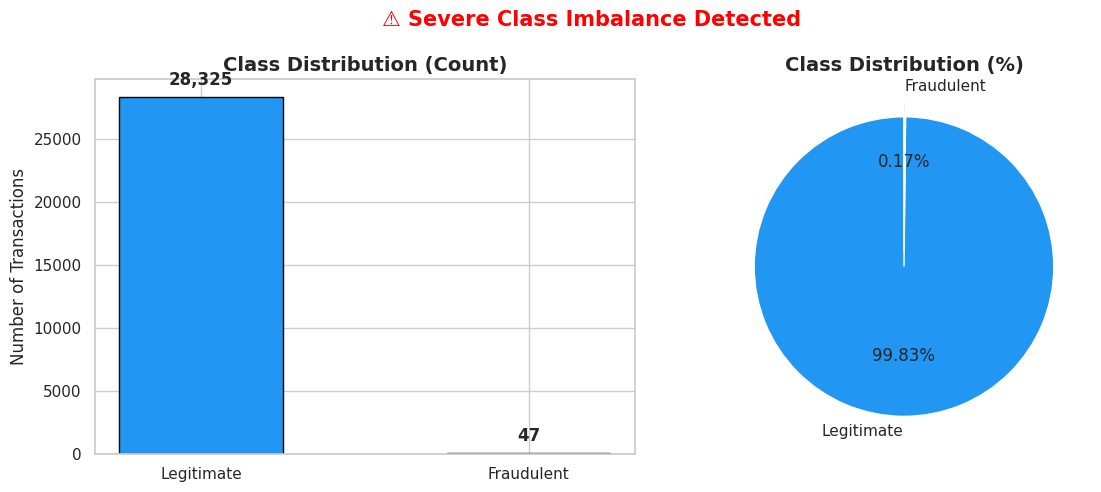

📊 Chart saved as class_imbalance.png


In [8]:
# Class distribution analysis
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(f'Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)')
print(f'Fraudulent  (1): {class_counts[1]:,} ({class_pct[1]:.2f}%)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.2f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('⚠️ Severe Class Imbalance Detected', fontsize=15, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved as class_imbalance.png')